In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

In [3]:
# =================================
# 1. Add Salt and Pepper Noise
# =================================

def salt_pepper_noise(image, amount=0.05):

    noisy = image.copy()

    total_pixels = image.size
    noise_pixels = int(total_pixels * amount)

    # Salt noise (white)
    for i in range(noise_pixels // 2):
        x = np.random.randint(0, image.shape[0])
        y = np.random.randint(0, image.shape[1])
        noisy[x, y] = 255

    # Pepper noise (black)
    for i in range(noise_pixels // 2):
        x = np.random.randint(0, image.shape[0])
        y = np.random.randint(0, image.shape[1])
        noisy[x, y] = 0

    return noisy

In [4]:
# =================================
# 2. Add Gaussian Noise
# =================================

def gaussian_noise(image, mean=0, sigma=25):

    noise = np.random.normal(mean, sigma, image.shape)

    noisy = image.astype(float) + noise

    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)


In [5]:
# =================================
# 3. Median Filter
# =================================

def median_filter(image):

    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            neighborhood = image[i-1:i+2, j-1:j+2]

            result[i, j] = np.median(neighborhood)

    return result

In [6]:

# =================================
# 4. Averaging Filter
# =================================

def average_filter(image):

    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            neighborhood = image[i-1:i+2, j-1:j+2]

            result[i, j] = np.mean(neighborhood)

    return result

In [7]:
# =================================
# Add Noise
# =================================

sp_noisy = salt_pepper_noise(image)
gaussian_noisy = gaussian_noise(image)

In [8]:
# =================================
# Restore Images
# =================================

sp_restored = median_filter(sp_noisy)

gaussian_restored = average_filter(gaussian_noisy)

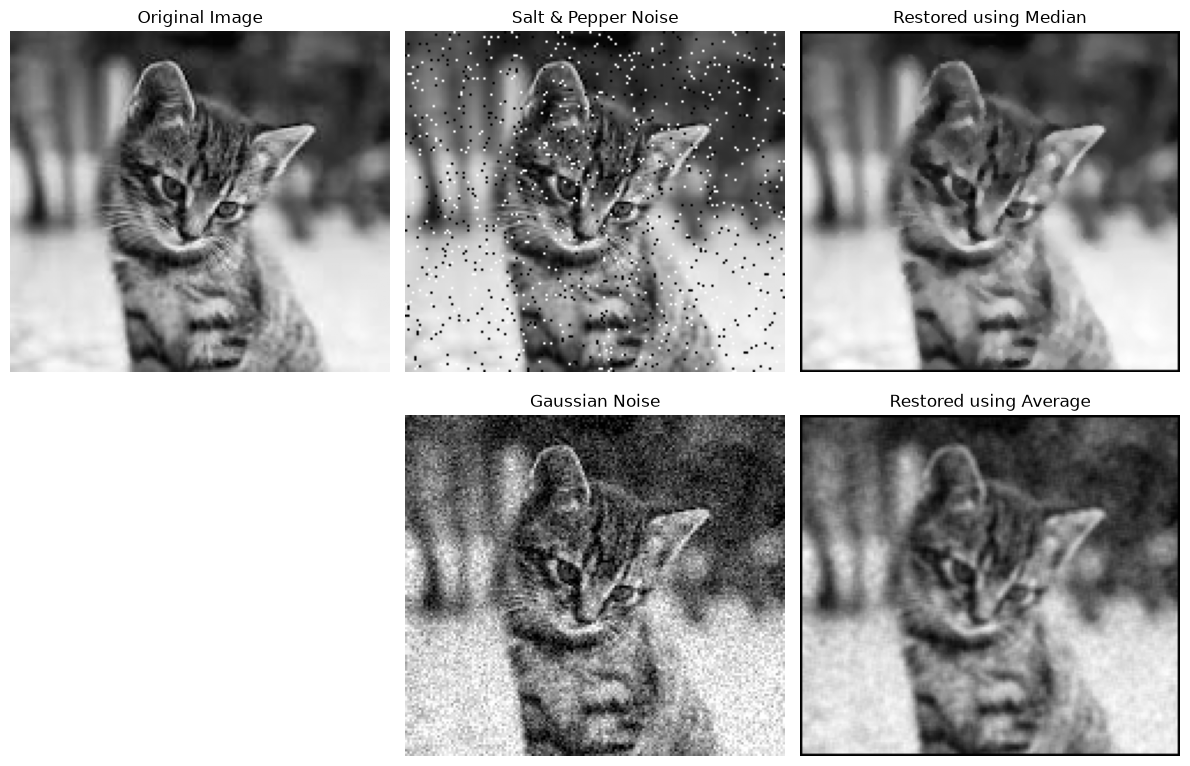

In [9]:
# =================================
# Display Results
# =================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(sp_noisy, cmap="gray")
plt.title("Salt & Pepper Noise")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(sp_restored, cmap="gray")
plt.title("Restored using Median")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(gaussian_noisy, cmap="gray")
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gaussian_restored, cmap="gray")
plt.title("Restored using Average")
plt.axis("off")

plt.tight_layout()
plt.show()